## Airbnb Price Prediction (Mexico City)

## 1. Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "http://data.insideairbnb.com/mexico/df/mexico-city/2024-12-27/data/listings.csv.gz"
df = pd.read_csv(url, compression='gzip')

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20241227033128,2024-12-27,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, ...","Santa Fe Shopping Mall, Interlomas Park and th...",https://a0.muscache.com/pictures/f395ab78-1185...,153786,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
1,44616,https://www.airbnb.com/rooms/44616,20241227033128,2024-12-28,city scrape,Condesa Haus,A new concept of hosting in mexico through a b...,NaN,https://a0.muscache.com/pictures/251410/ec75fe...,196253,...,4.78,4.98,4.48,NaN,f,8,4,1,0,0.40
2,67703,https://www.airbnb.com/rooms/67703,20241227033128,2024-12-28,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",NaN,https://a0.muscache.com/pictures/3281720/6f078...,334451,...,4.92,4.98,4.92,NaN,f,2,2,0,0,0.31
3,70644,https://www.airbnb.com/rooms/70644,20241227033128,2024-12-27,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,https://a0.muscache.com/pictures/f397d2da-d045...,212109,...,4.98,4.96,4.92,NaN,f,3,2,1,0,0.84
4,131610,https://www.airbnb.com/rooms/131610,20241227033128,2024-12-28,previous scrape,MARIA DEL ALMA,NaN,NaN,https://a0.muscache.com/pictures/837085/b9ed71...,647454,...,NaN,NaN,NaN,NaN,f,3,1,2,0,NaN


## 2. Data Cleaning

In [ ]:
df['price'] = (
    df['price']
    .replace('[\$,]', '', regex=True)
    .astype(float)
    .round()
    .astype('Int64')
)

df = df.dropna(subset=['price'])

columns_to_keep = [
    'id','listing_url','name','description','host_id','host_name',
    'host_total_listings_count','neighbourhood','latitude','longitude',
    'property_type','room_type','accommodates','bathrooms',
    'bedrooms','beds','amenities','price',
    'review_scores_rating','reviews_per_month'
]

df = df[columns_to_keep]

df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)
df['beds'].fillna(df['beds'].median(), inplace=True)

df['has_reviews'] = df['review_scores_rating'].notna().astype(int)
df['review_scores_rating'].fillna(0, inplace=True)
df['reviews_per_month'].fillna(0, inplace=True)

df['host_total_listings_count'].fillna(
    df['host_total_listings_count'].median(),
    inplace=True
)

df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_481/2005943025.py:3: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)
/tmp/ipykernel_481/2005943025.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
/tmp/ipykernel_481/2005943025.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The

## 3. Outlier Treatment

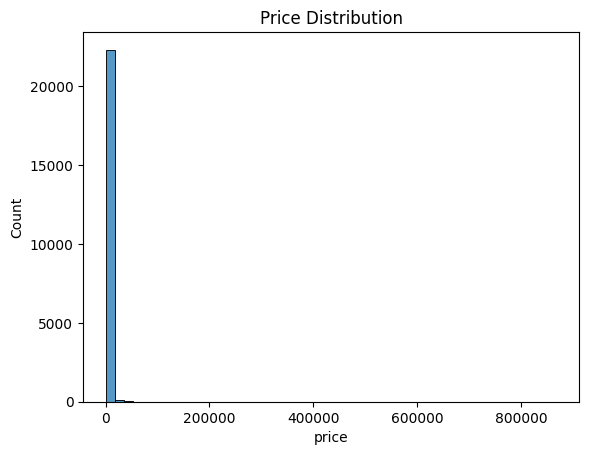

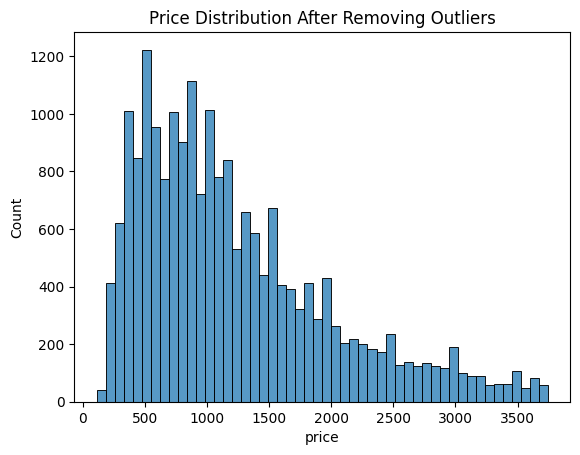

In [ ]:
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

sns.histplot(df['price'], bins=50)
plt.title("Price Distribution After Removing Outliers")
plt.show()

## 4. Exploratory Data Analysis

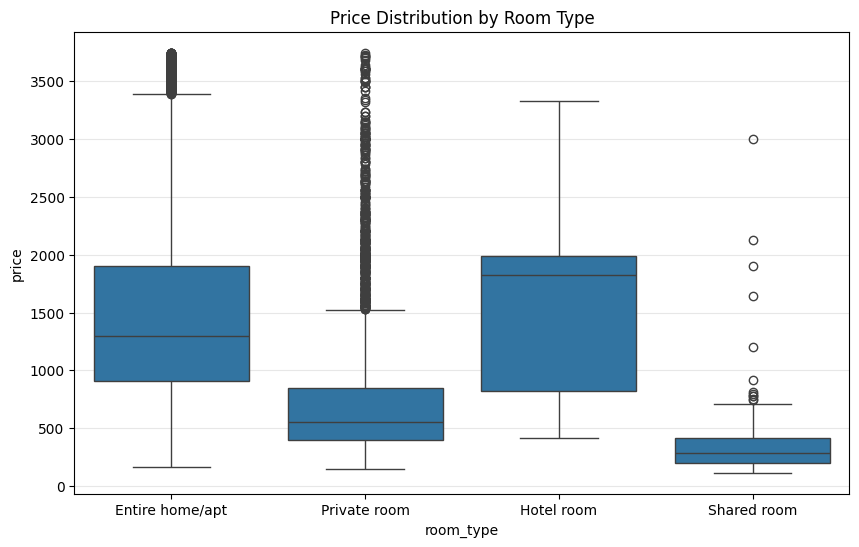

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='room_type', y='price', data=df)
plt.grid(axis='y', alpha=0.3)
plt.title("Price Distribution by Room Type")
plt.show()

## 5. Feature Engineering

In [ ]:
df['amenities_count'] = df['amenities'].apply(
    lambda x: x.count(',') + 1 if pd.notna(x) else 0
)

df.drop(columns=['amenities'], inplace=True)

df['lat_round'] = df['latitude'].round(2)
df['lon_round'] = df['longitude'].round(2)

df.drop(columns=['latitude','longitude'], inplace=True)

df = pd.get_dummies(
    df,
    columns=['neighbourhood','property_type','room_type'],
    drop_first=True
)

df.drop(columns=[
    'id','listing_url','name','description','host_name'
], inplace=True)

## 6. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['price', 'host_id'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 7. Baseline Model (Linear Regression)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression:", mae_lr, rmse_lr, r2_lr)

Linear Regression: 435.0577625255354 590.9474951394955 0.42974057124524023


## 8. Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:", mae_rf, rmse_rf, r2_rf)

Random Forest: 322.82660208679806 468.26446026703616 0.641938952835391


## 9. Model Comparison


The Random Forest model significantly outperformed the baseline Linear Regression model.

- MAE decreased substantially
- RMSE improved
- R² increased to ~0.65

This shows that non-linear models better capture pricing behavior.

## 11. Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestRegressor(n_estimators=200, random_state=42)

cv_r2 = cross_val_score(rf_cv, X, y, cv=5, scoring='r2')

print("Mean CV R2:", np.mean(cv_r2))
print("Std CV R2:", np.std(cv_r2))

Mean CV R2: 0.5547268904447061
Std CV R2: 0.04470358890173893


## 12. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

## 13. Feature Importance

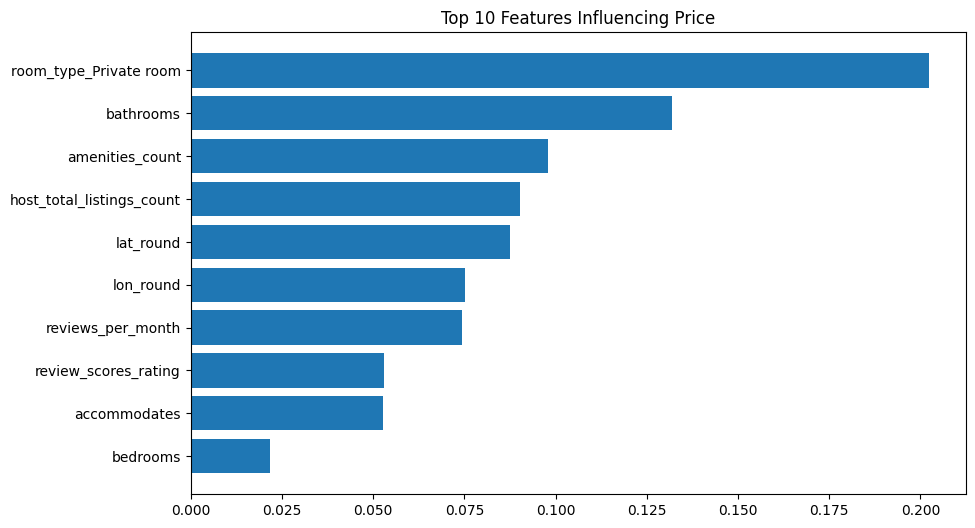

In [ ]:
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

top_n = 10

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df['feature'][:top_n][::-1],
    feature_importance_df['importance'][:top_n][::-1]
)

plt.title("Top 10 Features Influencing Price")
plt.show()

## 14. Predictions vs Actual

Tuned RF: 318.93558805062463 465.5483497258651 0.6460806844276393


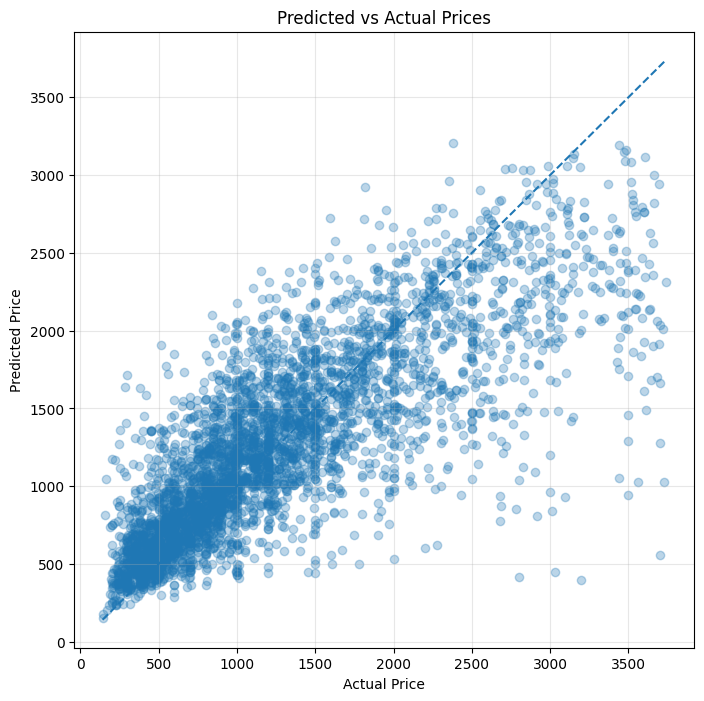

In [ ]:
y_pred_tuned = best_rf.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned RF:", mae_tuned, rmse_tuned, r2_tuned)

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_tuned, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.grid(alpha=0.3)
plt.show()

## 15. Conclusions

Airbnb prices are primarily driven by the following key factors:

- **Room type (Private room)**, which was the most important predictor, highlighting the strong impact of accommodation type on pricing

- **Number of bathrooms**, reflecting property quality and capacity

- **Amenities count**, capturing the level of comfort and services offered

These results indicate that property characteristics and listing quality are the main drivers of price, even more than raw location variables in this model.

The Random Forest model significantly outperformed Linear Regression, demonstrating that non-linear relationships are essential for capturing Airbnb pricing patterns.

Feature engineering played a critical role in improving performance, particularly:

- the creation of amenities_count
- spatial grouping using lat_round and lon_round (although less dominant than expected)

The model achieved an R² ≈ 0.65, indicating a solid ability to explain price variability.

Cross-validation results showed low variance, suggesting that the model is stable and generalizes well to unseen data.